In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = r"D:\JMM_Technologies\CryptoCurrency-Forecasting\data\processed_data"

In [3]:
def get_data(name):
	file_name = f"{name}.csv"
	file_path = os.path.join(PROJECT_DIR, file_name)
	return pd.read_csv(file_path)

# Trainig linear_regression on bitcoin

In [4]:
df = get_data("bitcoin_processed")

In [5]:
df.head()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2024-12-11 18:00:00,99781.89,100786.30,99608.23,100388.71,2207.59419,2024-12-11 18:59:59.999,2.213030e+08,472723,1125.00115,1.127619e+08
1,2024-12-11 19:00:00,100388.72,101141.01,100388.71,101122.71,1758.39622,2024-12-11 19:59:59.999,1.772703e+08,248186,1044.93146,1.053606e+08
2,2024-12-11 20:00:00,101122.71,101674.72,101024.75,101271.56,2068.71914,2024-12-11 20:59:59.999,2.096281e+08,348587,1022.62334,1.036290e+08
3,2024-12-11 21:00:00,101271.57,101536.70,100866.42,101520.12,1152.95810,2024-12-11 21:59:59.999,1.166446e+08,173600,532.68514,5.389223e+07
4,2024-12-11 22:00:00,101520.13,101888.00,101180.63,101209.74,1098.87478,2024-12-11 22:59:59.999,1.115587e+08,123585,533.97970,5.422886e+07


In [6]:
df['timestamp']

0      2024-12-11 18:00:00
1      2024-12-11 19:00:00
2      2024-12-11 20:00:00
3      2024-12-11 21:00:00
4      2024-12-11 22:00:00
              ...         
995    2025-01-22 05:00:00
996    2025-01-22 06:00:00
997    2025-01-22 07:00:00
998    2025-01-22 08:00:00
999    2025-01-22 09:00:00
Name: timestamp, Length: 1000, dtype: object

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Feature Engineering and Selection

In [8]:
# Extract time-based features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['week'] = df['timestamp'].dt.isocalendar().week
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   timestamp                     1000 non-null   datetime64[ns]
 1   open                          1000 non-null   float64       
 2   high                          1000 non-null   float64       
 3   low                           1000 non-null   float64       
 4   close                         1000 non-null   float64       
 5   volume                        1000 non-null   float64       
 6   close_time                    1000 non-null   object        
 7   quote_asset_volume            1000 non-null   float64       
 8   number_of_trades              1000 non-null   int64         
 9   taker_buy_base_asset_volume   1000 non-null   float64       
 10  taker_buy_quote_asset_volume  1000 non-null   float64       
 11  year                          1

In [10]:
# Moving Averages
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()
df['ma_20'] = df['close'].rolling(window=20).mean()

In [11]:
df['ema_5'] = df['close'].ewm(span=5, adjust=False).mean()
df['ema_10'] = df['close'].ewm(span=10, adjust=False).mean()

In [12]:
# Daily Percentage Change
df['daily_change'] = df['close'].pct_change()

In [13]:
# Volatility (Rolling Std Dev)
df['volatility_5'] = df['close'].rolling(window=5).std()
df['volatility_10'] = df['close'].rolling(window=10).std()

In [14]:
# RSI Calculation
def rsi(df, window=14):
    delta = df['close'].diff(1)
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    avg_gain = pd.Series(gain).rolling(window=window, min_periods=1).mean()
    avg_loss = pd.Series(loss).rolling(window=window, min_periods=1).mean()

    rs = avg_gain / (avg_loss + 1e-10)  # Avoid division by zero
    return 100 - (100 / (1 + rs))

df['rsi_14'] = rsi(df)

In [15]:
# Bollinger Bands (20-day rolling)
df['upper_band'] = df['ma_20'] + (df['close'].rolling(20).std() * 2)
df['lower_band'] = df['ma_20'] - (df['close'].rolling(20).std() * 2)


In [16]:
df.head()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,ma_10,ma_20,ema_5,ema_10,daily_change,volatility_5,volatility_10,rsi_14,upper_band,lower_band
0,2024-12-11 18:00:00,99781.89,100786.30,99608.23,100388.71,2207.59419,2024-12-11 18:59:59.999,2.213030e+08,472723,1125.00115,...,NaN,NaN,100388.710000,100388.710000,NaN,NaN,NaN,0.000000,NaN,NaN
1,2024-12-11 19:00:00,100388.72,101141.01,100388.71,101122.71,1758.39622,2024-12-11 19:59:59.999,1.772703e+08,248186,1044.93146,...,NaN,NaN,100633.376667,100522.164545,0.007312,NaN,NaN,100.000000,NaN,NaN
2,2024-12-11 20:00:00,101122.71,101674.72,101024.75,101271.56,2068.71914,2024-12-11 20:59:59.999,2.096281e+08,348587,1022.62334,...,NaN,NaN,100846.104444,100658.418264,0.001472,NaN,NaN,100.000000,NaN,NaN
3,2024-12-11 21:00:00,101271.57,101536.70,100866.42,101520.12,1152.95810,2024-12-11 21:59:59.999,1.166446e+08,173600,532.68514,...,NaN,NaN,101070.776296,100815.091307,0.002454,NaN,NaN,100.000000,NaN,NaN
4,2024-12-11 22:00:00,101520.13,101888.00,101180.63,101209.74,1098.87478,2024-12-11 22:59:59.999,1.115587e+08,123585,533.97970,...,NaN,NaN,101117.097531,100886.845615,-0.003057,425.556327,NaN,78.472593,NaN,NaN


In [17]:
df = df.drop(columns=['timestamp','close_time'], axis=1)

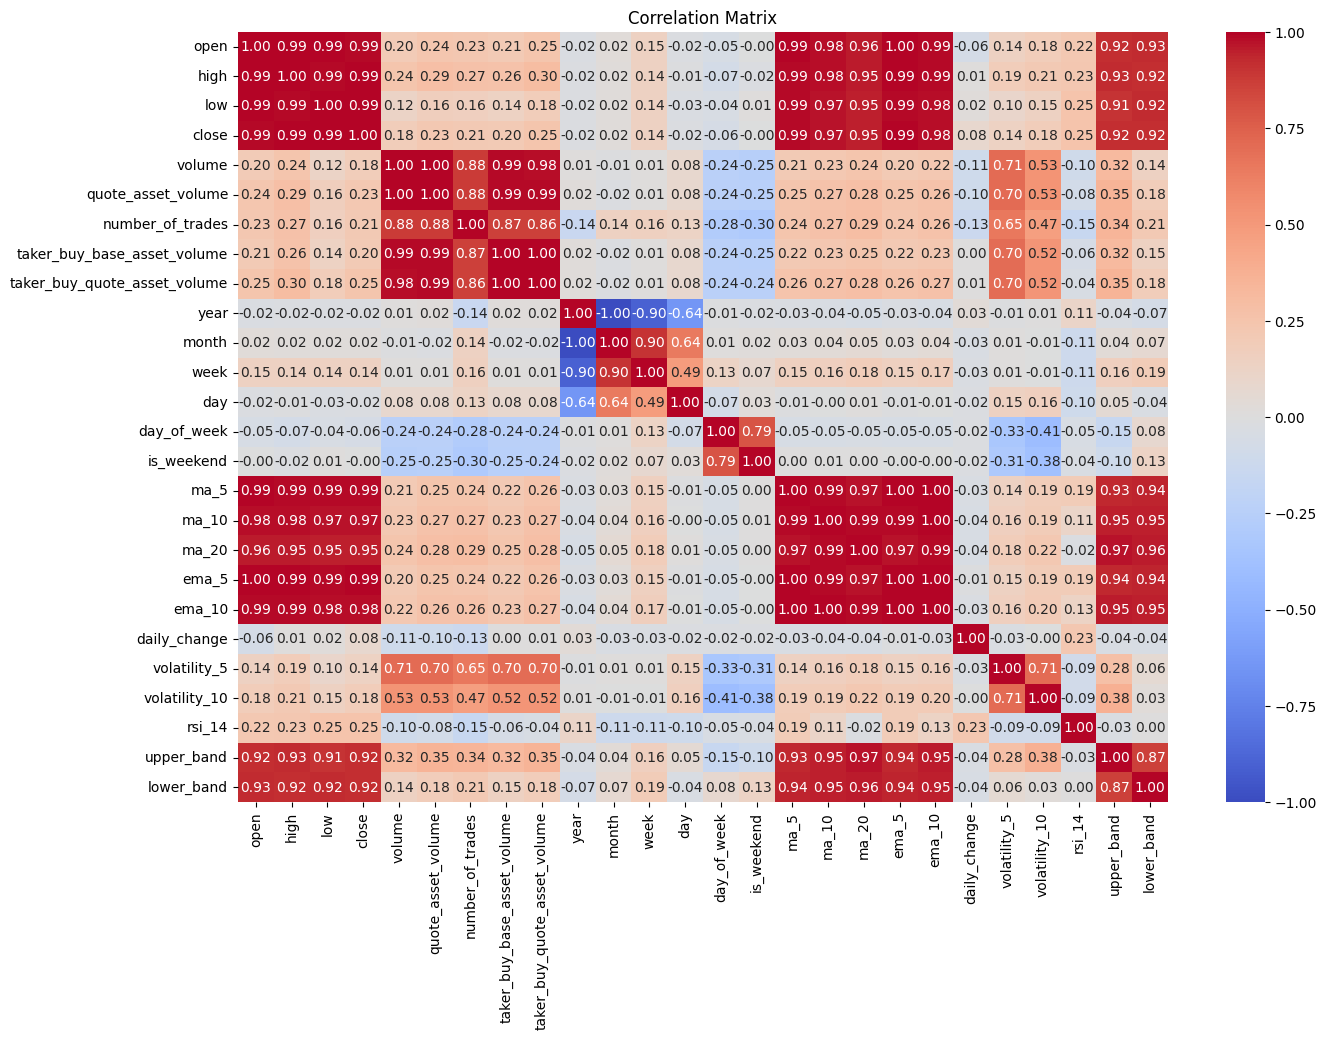

In [18]:
correlation_matrix = df.corr()

# Visualize using a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [31]:
# Compute correlation with the target column 'close'
correlation_matrix = df.corr()
close_correlation = correlation_matrix['close'].sort_values(ascending=False)

# Extract columns with correlation above 0.5
selected_features = close_correlation[close_correlation > 0.2].index.tolist()
df_selected = df[selected_features]

# Display selected features
print("Selected features with correlation > 0.5:\n", selected_features)
print(df_selected.head())
df_selected.to_csv("bitcoin_selected_features2.csv", index=False)


Selected features with correlation > 0.5:
 ['close', 'high', 'low', 'ema_5', 'open', 'ma_5', 'ema_10', 'ma_10', 'ma_20', 'lower_band', 'upper_band', 'rsi_14', 'taker_buy_quote_asset_volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume']
       close       high        low          ema_5       open        ma_5  \
0  100388.71  100786.30   99608.23  100388.710000   99781.89         NaN   
1  101122.71  101141.01  100388.71  100633.376667  100388.72         NaN   
2  101271.56  101674.72  101024.75  100846.104444  101122.71         NaN   
3  101520.12  101536.70  100866.42  101070.776296  101271.57         NaN   
4  101209.74  101888.00  101180.63  101117.097531  101520.13  101102.568   

          ema_10  ma_10  ma_20  lower_band  upper_band      rsi_14  \
0  100388.710000    NaN    NaN         NaN         NaN    0.000000   
1  100522.164545    NaN    NaN         NaN         NaN  100.000000   
2  100658.418264    NaN    NaN         NaN         NaN  100.000000   

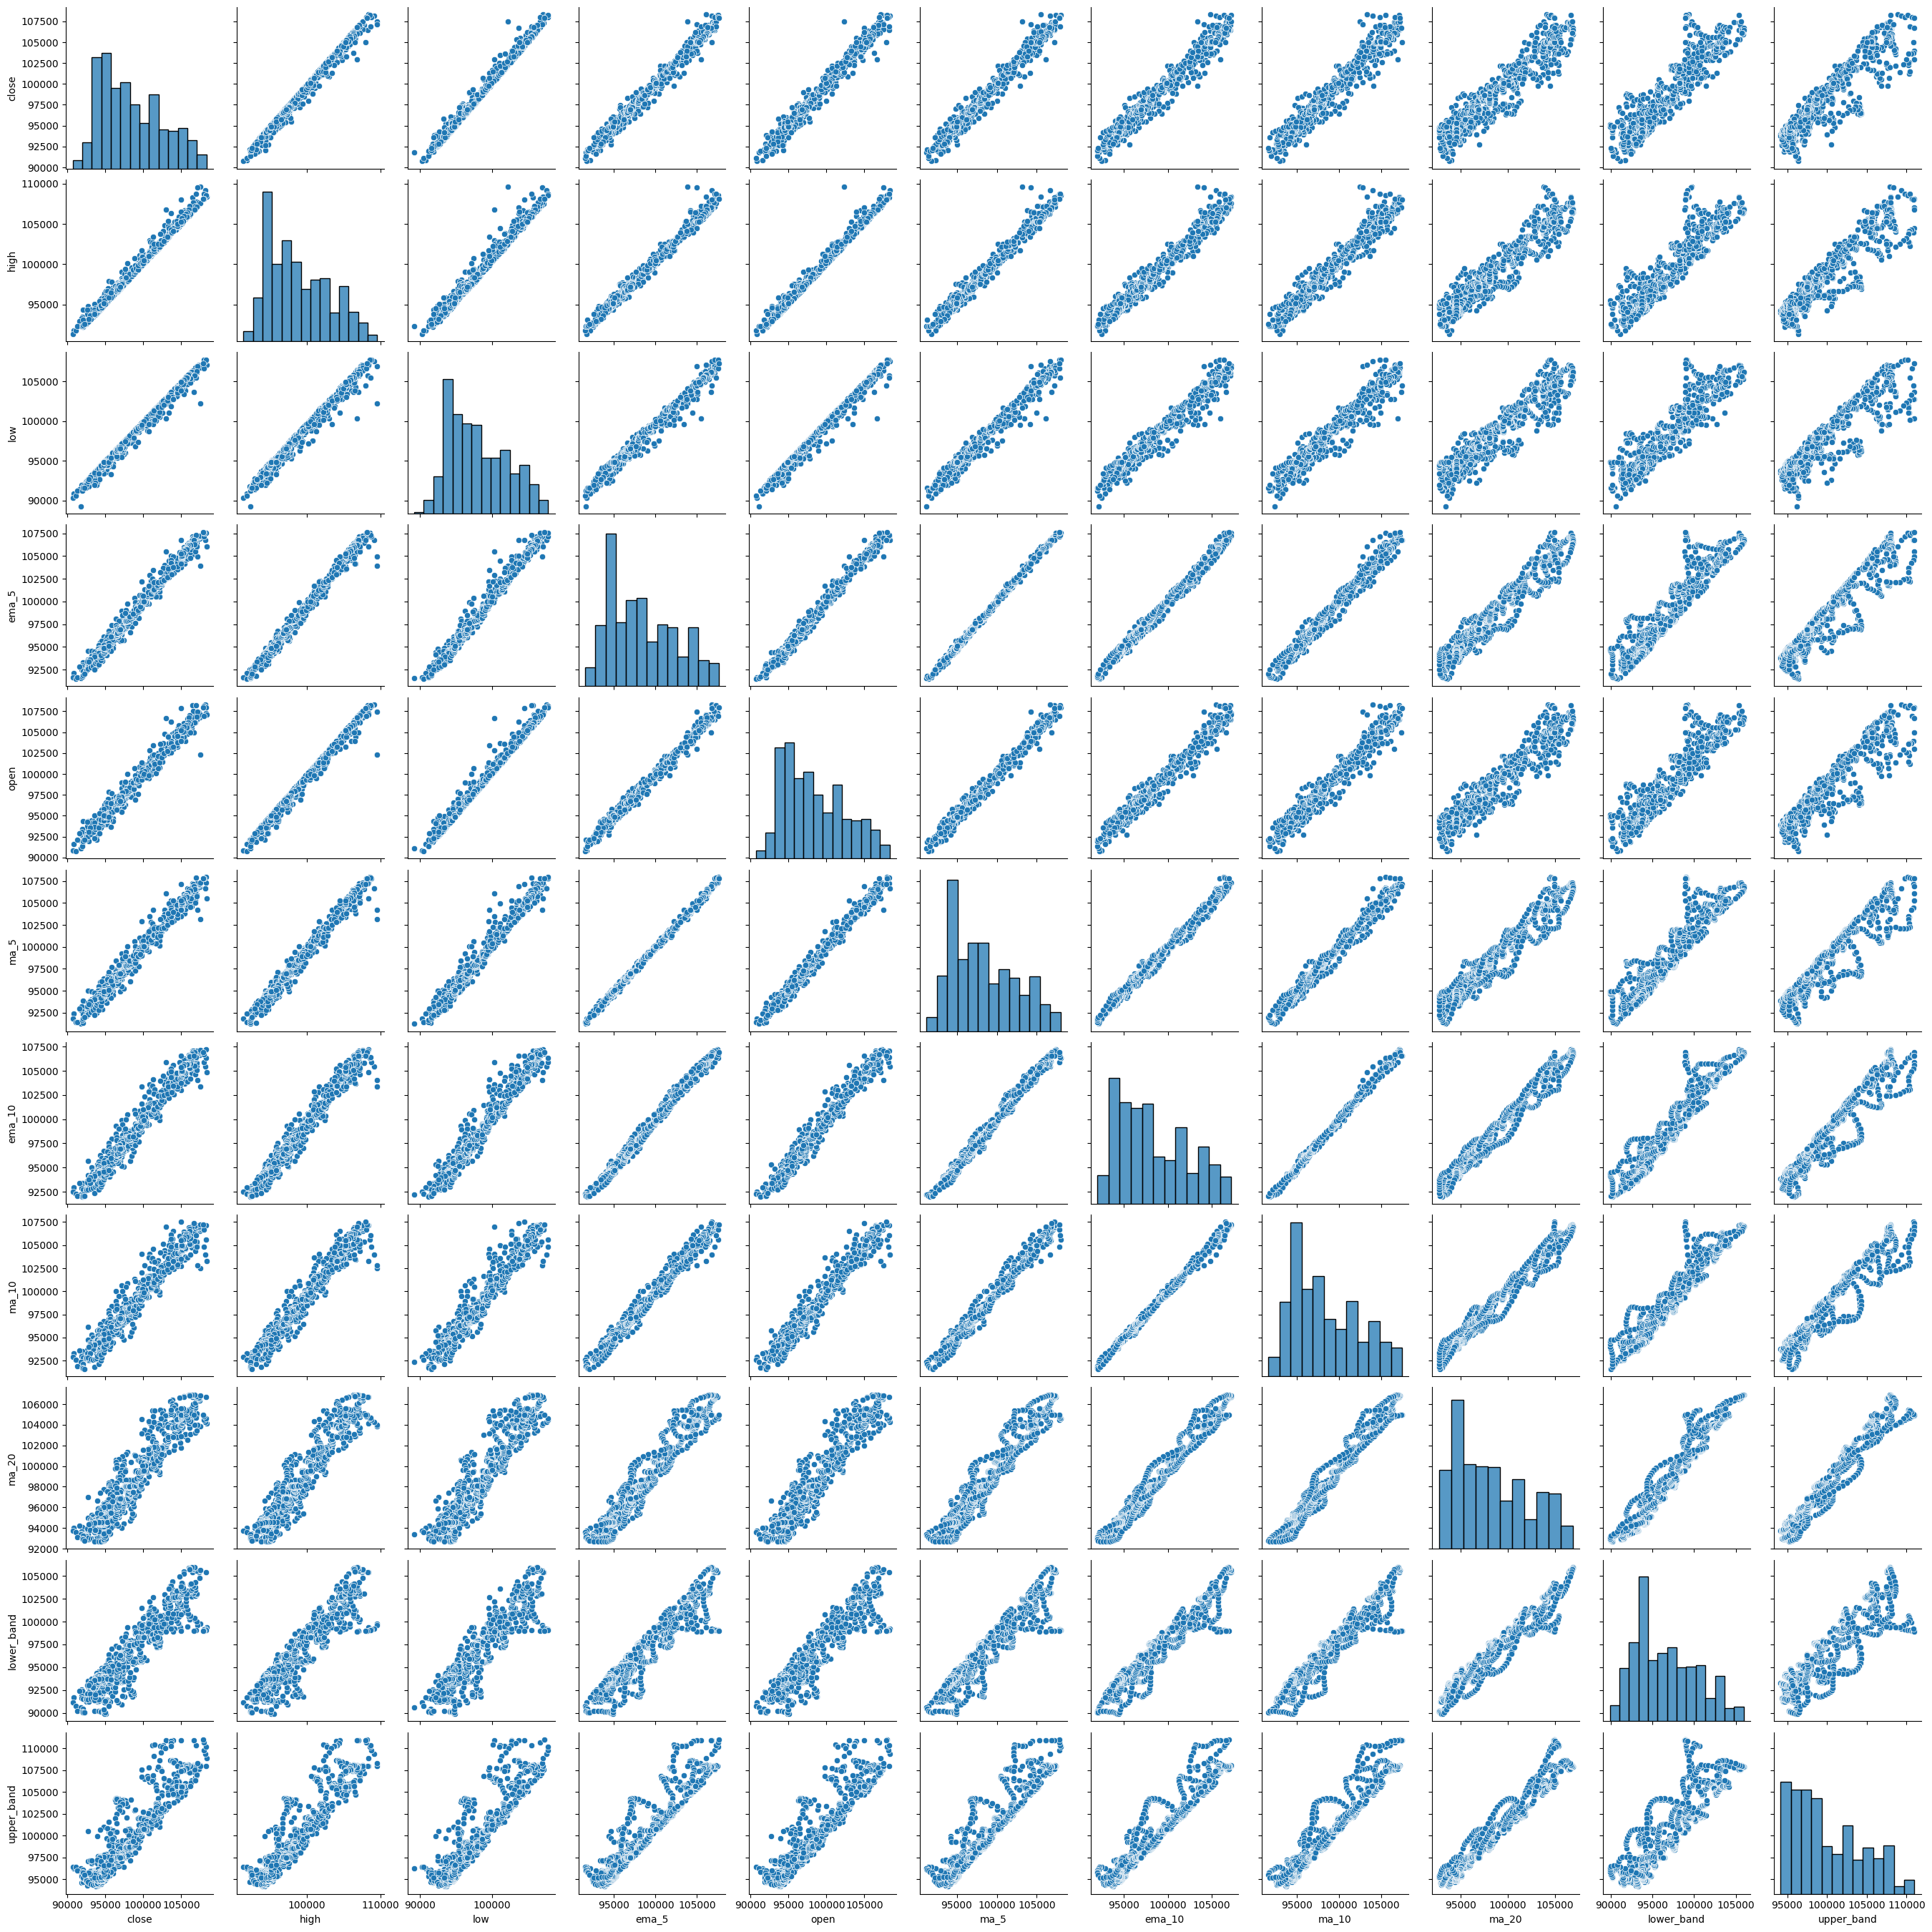

In [48]:
sns.pairplot(df1)

In [47]:
df1 = pd.read_csv('bitcoin_selected_features.csv')

In [44]:
df1.head()

,close,high,low,ema_5,open,ma_5,ema_10,ma_10,ma_20,lower_band,upper_band
0,100388.71,100786.30,99608.23,100388.710000,99781.89,NaN,100388.710000,NaN,NaN,NaN,NaN
1,101122.71,101141.01,100388.71,100633.376667,100388.72,NaN,100522.164545,NaN,NaN,NaN,NaN
2,101271.56,101674.72,101024.75,100846.104444,101122.71,NaN,100658.418264,NaN,NaN,NaN,NaN
3,101520.12,101536.70,100866.42,101070.776296,101271.57,NaN,100815.091307,NaN,NaN,NaN,NaN
4,101209.74,101888.00,101180.63,101117.097531,101520.13,101102.568,100886.845615,NaN,NaN,NaN,NaN


In [37]:
df1.isnull().sum()

close                           0
high                            0
low                             0
ema_5                           0
open                            0
ma_5                            0
ema_10                          0
ma_10                           0
ma_20                           0
lower_band                      0
upper_band                      0
rsi_14                          0
taker_buy_quote_asset_volume    0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
dtype: int64

In [36]:
df1['ma_5'] =  df1['ma_5'].fillna(df1['ma_5'].mean())
df1['ma_10'] = df1['ma_10'].fillna(df1['ma_10'].mean())
df1['ma_20'] = df1['ma_20'].fillna(df1['ma_20'].mean())
df1['lower_band'] = df1['lower_band'].fillna(df1['lower_band'].mean())
df1['upper_band'] = df1['upper_band'].fillna(df1['upper_band'].mean())

In [38]:
spearman_corr = df1.corr(method='spearman')
print(spearman_corr)

                                 close      high       low     ema_5  \
close                         1.000000  0.994599  0.994015  0.990861   
high                          0.994599  1.000000  0.989674  0.993324   
low                           0.994015  0.989674  1.000000  0.989877   
ema_5                         0.990861  0.993324  0.989877  1.000000   
open                          0.988597  0.993831  0.992404  0.994257   
ma_5                          0.985226  0.989445  0.985911  0.998238   
ema_10                        0.978877  0.983052  0.977915  0.995213   
ma_10                         0.969638  0.975110  0.968584  0.990002   
ma_20                         0.941335  0.947492  0.939601  0.964678   
lower_band                    0.911979  0.912890  0.916552  0.934134   
upper_band                    0.911533  0.922488  0.903662  0.933287   
rsi_14                        0.291287  0.272133  0.286529  0.232545   
taker_buy_quote_asset_volume  0.279123  0.322969  0.225022  0.28

In [39]:
X = df1.drop(columns=["close"])  
y = df1["close"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Chronological split (80% train, 20% test)
split_index = int(len(df1) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 123.19264123493026
Mean Squared Error (MSE): 27430.61805139753
Root Mean Squared Error (RMSE): 165.62191295658172
